In [16]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
"""Sources And Background Research:

https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn
https://medium.com/javarevisited/evaluating-the-logistic-regression-ae2decf42d61
https://www.datacamp.com/tutorial/svm-classification-scikit-learn-python
https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html
https://www.pycodemates.com/2022/10/the-rbf-kernel-in-svm-complete-guide.html
https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
https://www.geeksforgeeks.org/classification-using-sklearn-multi-layer-perceptron/
https://www.geeksforgeeks.org/numpy-ravel-python/

"""

In [18]:
#loading 
file_path = "data/mnist_10digits.mat"
mnist_data = scipy.io.loadmat(file_path)

#key names
X_train = mnist_data['xtrain'].reshape(60000, -1)  #flattening
y_train = mnist_data['ytrain'].ravel()

X_test = mnist_data['xtest'].reshape(10000, -1)
y_test = mnist_data['ytest'].ravel()

In [19]:
print(mnist_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'xtrain', 'ytrain', 'xtest', 'ytest'])


In [20]:
#normalizing  to [0,1] from 0, 255
X_train = X_train / 255.0
X_test = X_test / 255.0

# Downsample training data for KNN and SVM to 5000 samples for efficiency
X_train_small, _, y_train_small, _ = train_test_split(X_train, y_train, train_size=5000, stratify=y_train, random_state=42)


## KNN

In [21]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_small, y_train_small)
y_pred_knn = knn.predict(X_test)
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       980
           1       0.89      0.99      0.94      1135
           2       0.97      0.89      0.93      1032
           3       0.92      0.95      0.94      1010
           4       0.96      0.91      0.93       982
           5       0.94      0.91      0.92       892
           6       0.96      0.98      0.97       958
           7       0.92      0.93      0.93      1028
           8       0.98      0.86      0.92       974
           9       0.90      0.93      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.94      0.93      0.93     10000
weighted avg       0.94      0.93      0.93     10000



## Logistic Regression

In [22]:
log_reg = LogisticRegression(max_iter=500, solver='lbfgs', multi_class='multinomial')
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

/Users/zubairlakhia/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.93      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



## SVM Classifier (Linear)

In [23]:
svm = SVC(kernel='linear', C=1)
svm.fit(X_train_small, y_train_small)
y_pred_svm = svm.predict(X_test)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.94      0.98      0.96      1135
           2       0.90      0.89      0.89      1032
           3       0.88      0.91      0.90      1010
           4       0.91      0.93      0.92       982
           5       0.87      0.85      0.86       892
           6       0.94      0.95      0.94       958
           7       0.92      0.92      0.92      1028
           8       0.91      0.82      0.86       974
           9       0.90      0.89      0.90      1009

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## Kernel SVM (RBF Kernel)


In [24]:
kernel_svm = SVC(kernel='rbf', C=1, gamma='scale')
kernel_svm.fit(X_train_small, y_train_small)
y_pred_kernel_svm = kernel_svm.predict(X_test)
print("Kernel SVM Classification Report:")
print(classification_report(y_test, y_pred_kernel_svm))

Kernel SVM Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.95      0.95      0.95      1032
           3       0.94      0.96      0.95      1010
           4       0.94      0.95      0.95       982
           5       0.95      0.94      0.95       892
           6       0.96      0.97      0.97       958
           7       0.96      0.93      0.95      1028
           8       0.95      0.93      0.94       974
           9       0.94      0.93      0.93      1009

    accuracy                           0.96     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.96      0.96      0.96     10000



## Neural Network (MLP)

In [25]:

mlp = MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=500)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_mlp))

Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.96      0.93      0.94      1032
           3       0.93      0.95      0.94      1010
           4       0.95      0.97      0.96       982
           5       0.92      0.93      0.93       892
           6       0.95      0.96      0.96       958
           7       0.96      0.95      0.95      1028
           8       0.94      0.93      0.93       974
           9       0.94      0.93      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



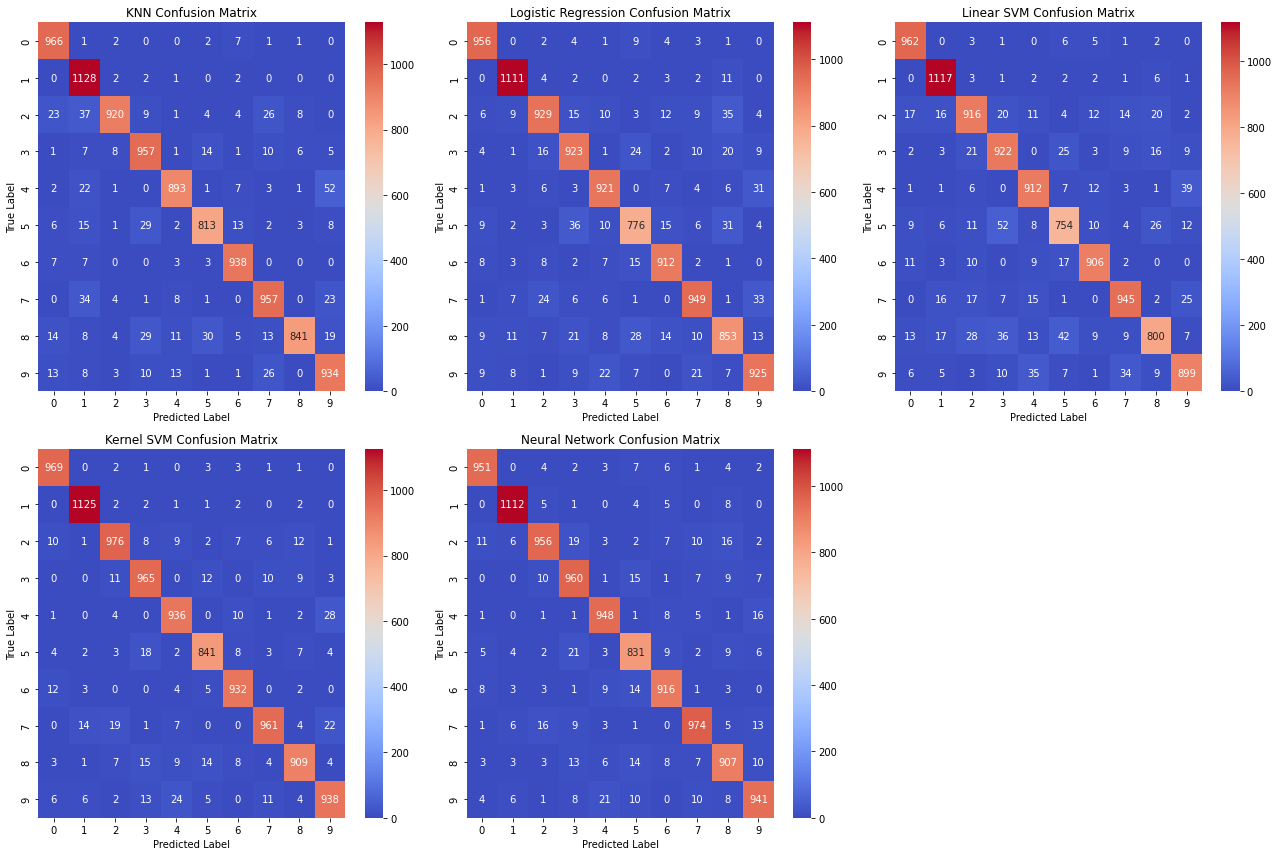

In [26]:
# Create confusion matrices
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_kernel_svm = confusion_matrix(y_test, y_pred_kernel_svm)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

# Set up subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))  
axes = axes.ravel()  

# Plot each confusion matrix
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(10), yticklabels=range(10), ax=axes[0])
axes[0].set_title("KNN Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(10), yticklabels=range(10), ax=axes[1])
axes[1].set_title("Logistic Regression Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

sns.heatmap(cm_svm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(10), yticklabels=range(10), ax=axes[2])
axes[2].set_title("Linear SVM Confusion Matrix")
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")

sns.heatmap(cm_kernel_svm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(10), yticklabels=range(10), ax=axes[3])
axes[3].set_title("Kernel SVM Confusion Matrix")
axes[3].set_xlabel("Predicted Label")
axes[3].set_ylabel("True Label")

sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(10), yticklabels=range(10), ax=axes[4])
axes[4].set_title("Neural Network Confusion Matrix")
axes[4].set_xlabel("Predicted Label")
axes[4].set_ylabel("True Label")

# Hide any unused subplot (since we have 5 matrices but a 2x3 grid)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


## QUESTION 6



In [4]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler

In [ ]:
"""Sources/Background Research:
https://ai-ml-analytics.com/Jupyter_notebook/Blog%20-%2020%20-%20Hyperparameter%20tuning%20using%20Ridge%20and%20Lasso%20Regression.html
- helped me to understand how to implement gridSearchCv to get a better alpha
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html
https://www.datacamp.com/tutorial/tutorial-lasso-ridge-regression
- background research/general information 
https://stackoverflow.com/questions/66978038/should-i-use-lassocv-or-gridsearchcv-to-find-an-optimal-alpha-for-lasso

"""

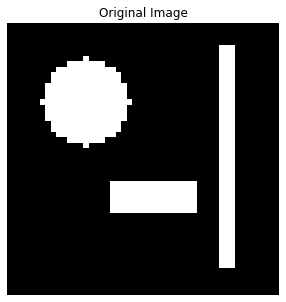

In [2]:
mat = scipy.io.loadmat('data/cs.mat')
data = mat['img']

# Display the original image
plt.figure(figsize=(5, 5))
plt.imshow(data, cmap='gray')
plt.title("Original Image")
plt.axis("off")  
plt.show()

Best Alpha: 0.02


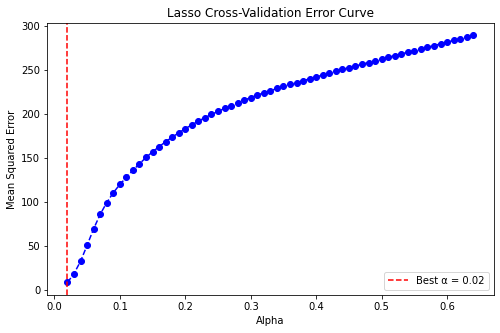

In [36]:


# Get the dimensions of the original image
n_pixels = data.size  # 2500 (50x50)

np.random.seed(6740)  # Keep randomness for reproducibility
n_pixels = data.size  
n_measurements = 1300  
A = np.random.randn(n_measurements, n_pixels)  
true_x = data.flatten()  
y = A @ true_x


# Grid Search for Best Alpha
model = Lasso(tol=1e-8, max_iter=100000)
cv = KFold(n_splits=10, random_state=5, shuffle=True)
#10 fold based on criteria in instructurions

#Since we are shrinking coeffecients to zero here I wanted to use relatively small values with a 
#small step size 
grid = {'alpha': np.arange(0.02, 0.65, 0.01)} 


# tuning with gridSearch to find the best alpha 
search = GridSearchCV(model, grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
results = search.fit(A, y)
best_alpha = results.best_params_['alpha']

print(f"Best Alpha: {best_alpha}")

# Recover the image using the best alpha
lasso_best = Lasso(alpha=best_alpha, tol=1e-8, max_iter=100000)
lasso_best.fit(A, y)
x_recovered = lasso_best.coef_.reshape(data.shape)

# extract mean test scores for plotting
alphas = grid['alpha']
mean_test_scores = -results.cv_results_['mean_test_score']  # Convert to positive MSE


#plottting curve
plt.figure(figsize=(8, 5))
plt.plot(alphas, mean_test_scores, marker='o', linestyle='dashed', color='b')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α = {best_alpha:.2f}')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Cross-Validation Error Curve')
plt.legend()
plt.show()


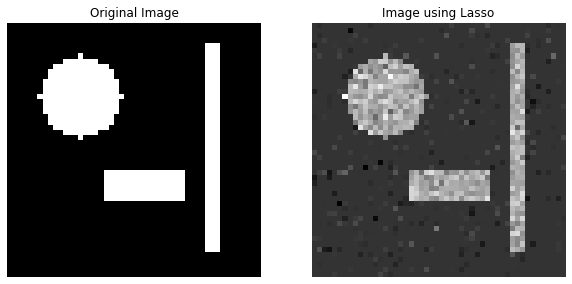

In [34]:
# Recover the image using the best alpha 
lasso_best = Lasso(alpha=best_alpha, tol=1e-8, max_iter=100000)
lasso_best.fit(A, y)
x_recovered = lasso_best.coef_.reshape(data.shape)  

# Display Results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(data, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(x_recovered, cmap='gray')
axes[1].set_title("Image using Lasso")
axes[1].axis("off")

plt.show()

# Ridge Regression Part B

In [45]:
np.random.seed(6740)  # Keep randomness for reproducibility
n_pixels = data.size  
n_measurements = 1300  
A = np.random.randn(n_measurements, n_pixels)  
true_x = data.flatten()  
y = A @ true_x

# Grid Search for Best Alpha (Lambda) using Ridge Regression
model = Ridge()
cv = KFold(n_splits=10, random_state=5, shuffle=True)

#ridge shrinks coeffs but never reaches 0 exactly. Handles bigger values better so I used larger ones here compared to lasso 
grid = {'alpha': np.logspace(-1, 2, 50)}  # Exploring lambda values from 10^-4 to 10^2

search = GridSearchCV(model, grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
results = search.fit(A, y)
best_alpha = results.best_params_['alpha']

print(f"Best Alpha for Ridge Regression: {best_alpha}")

Best Alpha for Ridge Regression: 0.1


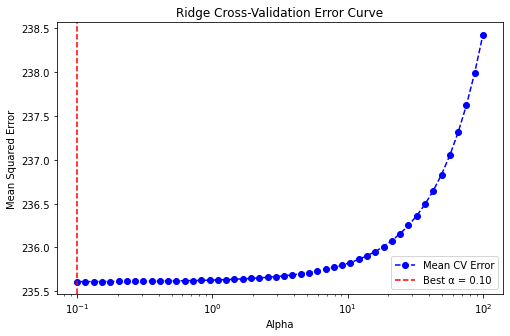

In [46]:
# extract values for Ridge cross-validation
alphas = grid['alpha']  # Lambda values tested
mean_test_scores = -results.cv_results_['mean_test_score']  # Convert negative MSE back to positive
best_alpha = results.best_params_['alpha']  # Best selected alpha

# Plot Cross-Validation Error Curve for Ridge Regression
plt.figure(figsize=(8, 5))
plt.plot(alphas, mean_test_scores, marker='o', linestyle='dashed', color='b', label="Mean CV Error")
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α = {best_alpha:.2f}')
plt.xscale("log")
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Cross-Validation Error Curve')
plt.legend()
plt.show()

In [43]:
#Did not have time to play around but my ridge regression alpha seems very small so it's not regularzing much.

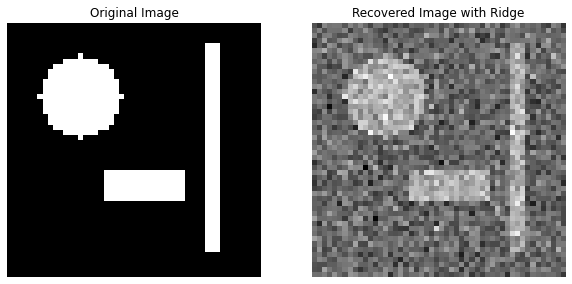

In [44]:
# Display results with best alpha
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(A, y)
x_recovered_ridge = ridge_best.coef_.reshape(data.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(data, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(x_recovered_ridge, cmap='gray')
axes[1].set_title("Recovered Image with Ridge")
axes[1].axis("off")

plt.show()